##TASK 3 – Energy Forecasting

This project focuses on forecasting energy consumption using historical time-based data.

The goal is to identify patterns in energy usage and predict future consumption
to support efficient energy management.

In [1]:
# This step imports libraries required for time series analysis and
# machine learning.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

In [2]:
# The dataset is loaded to analyze hourly energy consumption patterns.
df = pd.read_csv("PJME_hourly.csv")

df.head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [3]:
# The Datetime column is converted into proper datetime format and set as index.
df['Datetime'] = pd.to_datetime(df['Datetime'])
df.set_index('Datetime', inplace=True)

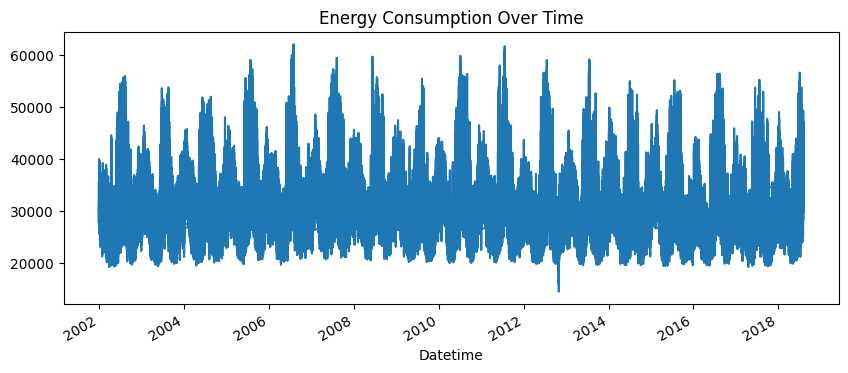

In [4]:
# This plot shows how energy consumption changes over time.
df['PJME_MW'].plot(figsize=(10,4))
plt.title("Energy Consumption Over Time")
plt.show()

In [6]:
# Time-based features such as hour, day, and month are extracted for modeling.
df['hour'] = df.index.hour
df['day'] = df.index.dayofweek
df['month'] = df.index.month

In [8]:
# The dataset is split into training and testing sets based on time.
train = df.iloc[:int(len(df)*0.8)]
test = df.iloc[int(len(df)*0.8):]

In [10]:
# XGBoost is used to predict energy consumption based on time features.
features = ['hour','day','month']

X_train = train[features]
y_train = train['PJME_MW']

X_test = test[features]
y_test = test['PJME_MW']

model = XGBRegressor()
model.fit(X_train, y_train)

pred = model.predict(X_test)

In [11]:
# Model performance is evaluated using MAE and RMSE.
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 3012.949684157237
RMSE: 3826.8420751858002


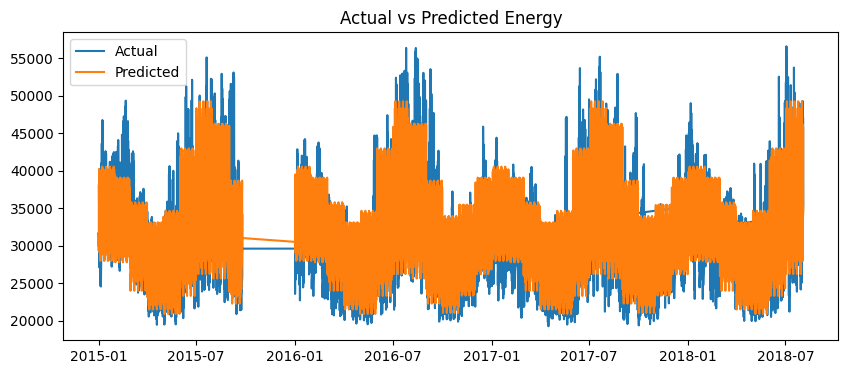

In [12]:
# This visualization compares actual and predicted energy values.
plt.figure(figsize=(10,4))

plt.plot(test.index, y_test, label="Actual")
plt.plot(test.index, pred, label="Predicted")

plt.legend()
plt.title("Actual vs Predicted Energy")

plt.show()

##Peak Hour Analysis

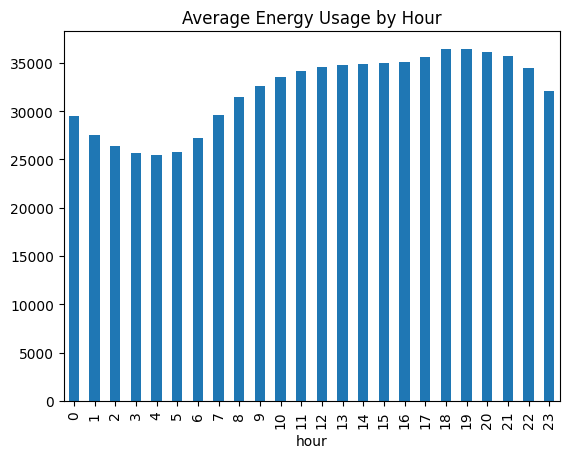

In [13]:
df.groupby('hour')['PJME_MW'].mean().plot(kind='bar')
plt.title("Average Energy Usage by Hour")
plt.show()

Energy consumption is highest during peak hours, indicating higher demand during specific times of the day.

##Conclusion
* project demonstrates how time series data can be used to forecast energy consumption based on historical patterns.

* By extracting time-based features such as hour, day, and month, the model was able to capture trends and variations in energy usage. The XGBoost model provided accurate predictions, showing that machine learning techniques can effectively handle time-dependent data.

* The analysis also revealed that energy consumption varies significantly across different hours of the day, indicating peak demand periods.

* These insights can help energy providers improve demand planning, optimize resource allocation, and reduce operational costs.